In [ ]:
import yfinance as yf
D = yf.download(["^IXIC","^GSPC"], start="2023-01-01", end ="2026-04-05")
D = D.dropna()
E = D['Close']

/tmp/ipykernel_5124/3770446320.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  D = yf.download(["^IXIC","^GSPC"], start="2023-01-01", end ="2026-04-05")
[*********************100%***********************]  2 of 2 completed


In [ ]:
full_data_df = yf.download(["^GSPC", "^IXIC"], start="2023-01-01" , end= "2026-04-02")

/tmp/ipykernel_5124/4250018279.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  full_data_df = yf.download(["^GSPC", "^IXIC"], start="2023-01-01" , end= "2026-04-02")
[*********************100%***********************]  2 of 2 completed


In [ ]:
F = full_data_df[["Close"]]
F.head()

Price             Close              
Ticker            ^GSPC         ^IXIC
Date                                 
2023-01-03  3824.139893  10386.980469
2023-01-04  3852.969971  10458.759766
2023-01-05  3808.100098  10305.240234
2023-01-06  3895.080078  10569.290039
2023-01-09  3892.090088  10635.650391

In [ ]:
import numpy as np
LF = np.log(F).dropna()
LF.head()

Price          Close          
Ticker         ^GSPC     ^IXIC
Date                          
2023-01-03  8.249089  9.248308
2023-01-04  8.256600  9.255195
2023-01-05  8.244886  9.240408
2023-01-06  8.267470  9.265708
2023-01-09  8.266702  9.271967

In [ ]:
LY = LF[[("Close", "^IXIC")]]
LX = LF[[("Close", "^GSPC")]]

In [ ]:
DLY = LY.diff().dropna()
DLX = LF.diff().dropna()

In [ ]:
import pandas as pd
H = pd.concat([LY, LX], axis=1)
H.head()

Price          Close          
Ticker         ^IXIC     ^GSPC
Date                          
2023-01-03  9.248308  8.249089
2023-01-04  9.255195  8.256600
2023-01-05  9.240408  8.244886
2023-01-06  9.265708  8.267470
2023-01-09  9.271967  8.266702

In [ ]:
from statsmodels.tsa.api import ARDL

In [ ]:
from statsmodels.tsa.ardl import ardl_select_order

In [ ]:
sel_res = ardl_select_order(LY, 5, LX, 5, ic="aic", trend="c")
print(f"El orden optimo para Y; X: {sel_res.model.ardl_order}")

El orden optimo para Y; X: (1, 1)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
modARDL12 = ARDL(LY, 1, LX, 1)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
ARDL12 =modARDL12.fit()
print(ARDL12.summary())

                              ARDL Model Results                              
Dep. Variable:            Close_^IXIC   No. Observations:                  814
Model:                     ARDL(1, 1)   Log Likelihood                3459.240
Method:               Conditional MLE   S.D. of innovations              0.003
Date:                Thu, 16 Apr 2026   AIC                          -6908.479
Time:                        01:34:38   BIC                          -6884.975
Sample:                             1   HQIC                         -6899.457
                                  814                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.0135      0.008     -1.630      0.104      -0.030       0.003
Close_^IXIC.L1            0.9750      0.006    158.315      0.000       0.963       0.987
('Close'

<Axes: xlabel='Date'>

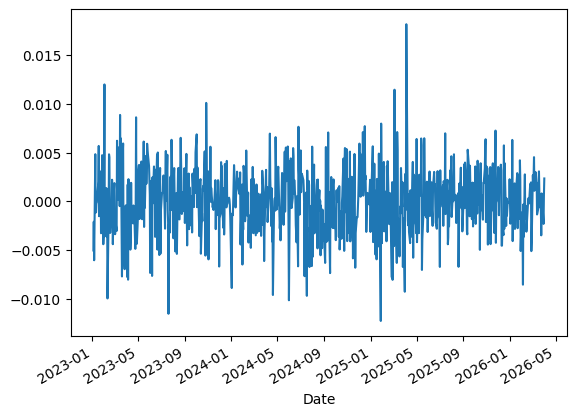

In [ ]:
INN_ARDL = ARDL12.resid
INN_ARDL.plot()

In [ ]:
import statsmodels.api as sm
sm.stats.acorr_ljungbox(INN_ARDL, lags=[1], return_df=True)

,lb_stat,lb_pvalue
1,0.110924,0.739094


In [ ]:
INN_ARDL2 = INN_ARDL*INN_ARDL
sm.stats.acorr_ljungbox(INN_ARDL2, lags=[1], return_df=True)

,lb_stat,lb_pvalue
1,0.002493,0.960178


In [ ]:
from scipy.stats import normaltest
JB = normaltest(INN_ARDL)
print(JB)

NormaltestResult(statistic=np.float64(21.703132835110004), pvalue=np.float64(1.937423596523096e-05))


In [ ]:
from statsmodels.tsa.api import UECM

In [ ]:
ecm = UECM.from_ardl(modARDL12)
ecm_res = ecm.fit()
print(ecm_res.summary())

                               UECM Model Results                               
Dep. Variable:     D.('Close', '^IXIC')   No. Observations:                  814
Model:                       UECM(1, 1)   Log Likelihood                3459.240
Method:                 Conditional MLE   S.D. of innovations              9.741
Date:                  Thu, 16 Apr 2026   AIC                          -6908.479
Time:                          01:51:17   BIC                          -6884.975
Sample:                               1   HQIC                         -6899.457
                                    814                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -0.0135      0.008     -1.630      0.104      -0.030       0.003
('Close', '^IXIC').L1      -0.0250      0.006     -4.058      0.000      -0.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
print(ecm_res.ci_summary())

                                   Cointegrating Vector                                  
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.5386      0.257      2.100      0.036       0.035       1.042
('Close', '^IXIC').L1     1.0000          0        nan        nan       1.000       1.000
('Close', '^GSPC').L1    -1.1976      0.030    -40.116      0.000      -1.256      -1.139


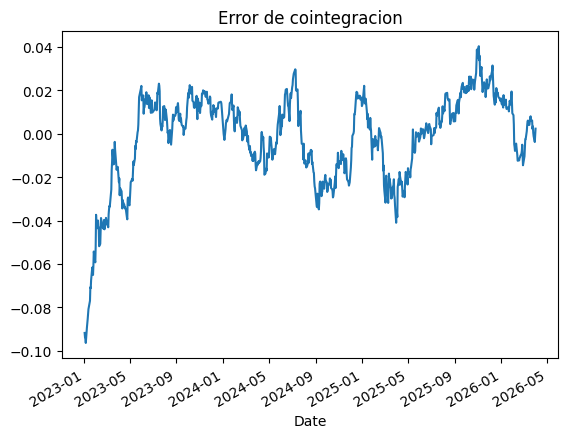

In [ ]:
_ = ecm_res.ci_resids.plot(title="Error de cointegracion")

In [ ]:
import statsmodels.api as sm

In [ ]:
sm.stats.acorr_ljungbox(ecm_res.ci_resids, lags=[1], return_df=True)

,lb_stat,lb_pvalue
1,776.274464,7.771710e-171


In [ ]:
INN_CE2 = ecm_res.ci_resids * ecm_res.ci_resids
sm.stats.acorr_ljungbox(INN_CE2, lags=[1], return_df=True)

,lb_stat,lb_pvalue
1,734.400851,9.891576e-162


In [ ]:
from scipy.stats import normaltest
JBCE = normaltest(ecm_res.ci_resids)
JBCE

NormaltestResult(statistic=np.float64(185.76310115139265), pvalue=np.float64(4.592562912869837e-41))